# Character-Level Language Model for the Shakespeare Dataset

*A stateful GRU network built with TensorFlow 2 / Keras that learns to predict the next character in Shakespeare's plays and then writes its own text.*

The goal of this project is to build a character-level language model: preprocess raw text with Keras tools, train a recurrent neural network on the works of Shakespeare and use the trained network to generate new text, one character at a time.

The notebook goes through the whole workflow: load and inspect the text, tokenize it at character level, pad the sequences, build the inputs and shifted targets, prepare the data for a stateful RNN, train a GRU model, read the learning curves and write a sampling algorithm to generate text from a seed string.

## 1. Libraries and setup

TensorFlow and Keras provide the tokenizer, the padding tool, the `Dataset` API and the layers of the model. NumPy and Matplotlib handle the arrays and the plots, and `json` is used to save and load the training history.

In [1]:
# Package Imports

import tensorflow as tf
import numpy as np
import json
import matplotlib.pyplot as plt
%matplotlib inline

##
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.data import Dataset

from tensorflow.keras.layers import Embedding, GRU, RNN, Dense, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint

from tensorflow.keras.losses import SparseCategoricalCrossentropy


## 2. The Shakespeare dataset

![imagen-shakespeare](data/shakespeare.png)

A subset of the [Shakespeare dataset](http://shakespeare.mit.edu) is used. It is a single plain-text file (about 1.1 million characters) with several excerpts from different plays concatenated together. The text is raw: it has no preprocessing at all, so speaker names, punctuation, capital letters and line breaks are all still there.

The goal is to build an unsupervised, character-level sequence model that can generate text following the distribution it learned from the data.

## 3. Load and inspect the data

The file is read into one long string and cut into smaller chunks so it can be tokenized and padded later.

In [2]:
# Load text file into a string

with open('data/Shakespeare.txt', 'r', encoding='utf-8') as file:
    text = file.read()


In [3]:
#Printing 1000 letters of the string text

text[:1000]

"First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you know Caius Marcius is chief enemy to the people.\n\nAll:\nWe know't, we know't.\n\nFirst Citizen:\nLet us kill him, and we'll have corn at our own price.\nIs't a verdict?\n\nAll:\nNo more talking on't; let it be done: away, away!\n\nSecond Citizen:\nOne word, good citizens.\n\nFirst Citizen:\nWe are accounted poor citizens, the patricians good.\nWhat authority surfeits on would relieve us: if they\nwould yield us but the superfluity, while it were\nwholesome, we might guess they relieved us humanely;\nbut they think we are too dear: the leanness that\nafflicts us, the object of our misery, is as an\ninventory to particularise their abundance; our\nsufferance is a gain to them Let us revenge this with\nour pikes, ere we become rakes: for the gods know I\nspeak this in hunger 

The text is structured like a play script: the speaker's name in capitals followed by a colon, and then their lines separated by line breaks. The model has to learn this format along with the words themselves.

In [4]:
# Creating a list of chunks of text
# We separate the sentences

text_chunks = text.split('.') 


The text is split at every full stop (`.`), which gives roughly one chunk per sentence. This keeps the sequences much shorter than the full 1.1M-character text.

In [5]:
# Looking the first 10 chunks
text_chunks[:10]


['First Citizen:\nBefore we proceed any further, hear me speak',
 '\n\nAll:\nSpeak, speak',
 '\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved',
 ' resolved',
 '\n\nFirst Citizen:\nFirst, you know Caius Marcius is chief enemy to the people',
 "\n\nAll:\nWe know't, we know't",
 "\n\nFirst Citizen:\nLet us kill him, and we'll have corn at our own price",
 "\nIs't a verdict?\n\nAll:\nNo more talking on't; let it be done: away, away!\n\nSecond Citizen:\nOne word, good citizens",
 '\n\nFirst Citizen:\nWe are accounted poor citizens, the patricians good',
 '\nWhat authority surfeits on would relieve us: if they\nwould yield us but the superfluity, while it were\nwholesome, we might guess they relieved us humanely;\nbut they think we are too dear: the leanness that\nafflicts us, the object of our misery, is as an\ninventory to particularise their abundance; our\nsufferance is a gain to them Let us revenge this with\nour pikes, ere we become rakes: for t

Chunks vary a lot in length. Some are a single short sentence, and others are longer or even include a speaker change, since the split only looks at full stops.

A few chunks picked at random, to get a feel for how different they are from each other.

In [6]:
# Print 10 random chunks
num_samples = 10
idx = np.random.choice(len(text_chunks), num_samples, replace=False)
for chunck in np.array(text_chunks)[idx]:
    print(chunck)



PAULINA:
So much the more our carver's excellence;
Which lets go by some sixteen years and makes her
As she lived now

These, as I learn, and such like toys as these
Have moved his highness to commit me now


DUKE VINCENTIO:
Hath he born himself penitently in prison? how
seems he to be touched?

Provost:
A man that apprehends death no more dreadfully but
as a drunken sleep; careless, reckless, and fearless
of what's past, present, or to come; insensible of
mortality, and desperately mortal


LUCENTIO:
I thank thee for that gird, good Tranio


RIVERS:
My Lord of Gloucester, in those busy days
Which here you urge to prove us enemies,
We follow'd then our lord, our lawful king:
So should we you, if you should be our king
 Hark! what noise is this?

QUEEN ELIZABETH:
Oh, who shall hinder me to wail and weep,
To chide my fortune, and torment myself?
I'll join with black despair against my soul,
And to myself become an enemy


CLAUDIO:
I humbly thank you


DUKE OF YORK:
It was, villain, ere

Besides the usual verses, the chunks include the speaker headers (`DUKE VINCENTIO:`, `QUEEN ELIZABETH:`), so the model will see them too.

## 4. Character-level tokenizer

Neural networks cannot read letters, so every character is mapped to an integer id. Keras' `Tokenizer` with `char_level=True` does this: each distinct character becomes a token. Upper and lower case are kept as different tokens (`lower=False`) and no characters are filtered out, so punctuation and line breaks are part of the vocabulary too.

In [7]:
# char_level=True: each character is one token, keeping upper/lower case
def create_character_tokenizer(list_of_strings):

    tokenizer = Tokenizer(
        num_words=None,
        filters='',
        lower= False,
        char_level = True,
        oov_token='<UNK>',
    )
    tokenizer.fit_on_texts(list_of_strings)
    return tokenizer




In [8]:
#Getting the tokenizer

tokenizer = create_character_tokenizer(text_chunks)


In [9]:
# Tokenizer config: vocabulary and how many times each character appears
tokenizer_config = tokenizer.get_config()
print(tokenizer_config)
print(tokenizer_config.keys())
print(tokenizer_config['word_counts'])

{'num_words': None, 'filters': '', 'lower': False, 'split': ' ', 'char_level': True, 'oov_token': '<UNK>', 'document_count': 7886, 'word_counts': '{"F": 1797, "i": 45537, "r": 48889, "s": 49696, "t": 67009, " ": 169892, "C": 3820, "z": 356, "e": 94611, "n": 48529, ":": 10316, "\\n": 40000, "B": 2761, "f": 15770, "o": 65798, "w": 17585, "p": 10808, "c": 15623, "d": 31358, "a": 55507, "y": 20448, "u": 26584, "h": 51310, ",": 19846, "m": 22243, "k": 7088, "A": 7819, "l": 33339, "S": 4523, "Y": 1718, "v": 7793, "?": 2462, "R": 4869, "M": 2840, "W": 3530, "\'": 6187, "L": 3876, "I": 11832, "N": 5079, "g": 13356, ";": 3628, "b": 11321, "!": 2172, "O": 5481, "j": 628, "V": 798, "-": 1897, "T": 7015, "H": 3068, "E": 6041, "U": 3313, "D": 2089, "P": 1641, "q": 609, "x": 529, "J": 320, "G": 2399, "K": 1584, "Q": 231, "&": 3, "Z": 198, "X": 112, "3": 27, "$": 1}', 'word_docs': '{":": 6460, "p": 4562, "n": 7229, "u": 6580, "z": 310, "a": 7414, "h": 7282, "m": 6454, " ": 7866, "B": 2146, "s": 7260,

The text is made of **64 different characters** spread over 7,886 chunks (`document_count`). Some observations from the counts:

* The most frequent character is the space (169,892 times), followed by `e` (94,611) and `t` (67,009). The line break `\n` appears 40,000 times.
* Rare characters like `&` (3 times), `3` (27) or `$` (1) will be almost impossible for the model to learn.
* Id `1` is reserved for `<UNK>`, so the real characters start at id `2`. Adding `<UNK>` and the padding id `0`, the vocabulary size for the model is `64 + 2 = 66` (the `len(word_index) + 1` used later).

### 4.1 Tokenize the text

Every chunk is converted into a list of integer ids.

In [10]:
# Turn each chunk of text into a list of integer ids
def strings_to_sequences(tokenizer, list_of_strings):

    sentence_sequence = tokenizer.texts_to_sequences(list_of_strings)

    return sentence_sequence


In [11]:
seq_chunks = strings_to_sequences(tokenizer, text_chunks)

In [12]:
print(len(seq_chunks))
print(len(seq_chunks[0]))
print(seq_chunks[0])


7886
59
[50, 11, 9, 8, 4, 2, 38, 11, 4, 11, 58, 3, 10, 26, 12, 44, 3, 20, 5, 9, 3, 2, 19, 3, 2, 25, 9, 5, 21, 3, 3, 14, 2, 6, 10, 17, 2, 20, 15, 9, 4, 7, 3, 9, 18, 2, 7, 3, 6, 9, 2, 16, 3, 2, 8, 25, 3, 6, 29]


There are 7,886 sequences, and the first chunk (59 characters) became a list of 59 integer ids.

## 5. Padding the sequences

The chunks have very different lengths, but the model needs fixed-size arrays. `pad_sequences` pads (or truncates) every sequence to 500 tokens, adding zeros at the beginning. The id `0` is never given to a real character, so it can be ignored later with `mask_zero=True` in the embedding layer.

In [13]:
# Pad/truncate every sequence to 500 tokens, with zeros on the left
def make_padded_dataset(sequence_chunks):

    sequence_padded = pad_sequences(sequence_chunks,
                                    maxlen=500,
                                    padding='pre',
                                    truncating='pre',
                                    value=0)

    return sequence_padded

In [14]:
#Padding the token sequence chunks and getting the numpy array

padded_sequences = make_padded_dataset(seq_chunks)



In [15]:
print(padded_sequences.shape)
print(padded_sequences[55])



(7886, 500)
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0

The array has shape `(7886, 500)`. In the sequence printed above, the zeros on the left are the padding and the real characters sit at the end of the row.

## 6. Inputs and targets

### 6.1 Shifted targets

The model receives a sequence of characters and has to predict the next character at every position. For training, the target sequence is just the input sequence shifted by one step.

For example, the expression `To be or not to be` appears in Shakespeare's play *Hamlet*. Given the input `To be or not to b`, the correct prediction is `o be or not to be`. The prediction has the same length as the input.

![image-example](data/rnn_example.png)

In [16]:
# Input = all but the last token, target = same sequence shifted by one
def create_inputs_and_targets(array_of_sequences):

    input_array = array_of_sequences[:, :-1]
    output_array = array_of_sequences[:, 1:]

    return (input_array, output_array)



In [17]:
# Input and output arrays

input_seq, target_seq = create_inputs_and_targets(padded_sequences)



`input_seq` and `target_seq` both have 499 columns: the input drops the last token and the target drops the first one.

### 6.2 Preprocess the arrays for a stateful RNN

The GRU is built to be *stateful*: its hidden state is **not** reset between batches, so the network can carry information from one batch to the next. For that to make sense, row `k` of batch `n+1` must be the continuation of row `k` of batch `n`.

To get this, the number of examples is first trimmed to a multiple of the batch size, and then the rows are reordered: instead of consecutive chunks going into the same batch, each batch takes one chunk from every "slot" of the dataset, spaced `steps` positions apart.

In [18]:

#Batch size for training

batch_size = 32


In [19]:
# Reorder the rows so each batch continues the previous one (stateful RNN)
#Preparing the input and output arrays for training stateful RNN

num_examples = input_seq.shape[0]

num_processed_examples = num_examples - (num_examples % batch_size)

input_seq = input_seq[:num_processed_examples]
target_seq = target_seq[:num_processed_examples]

steps = int(num_processed_examples / 32)

idx = np.empty((0,), dtype=np.int32)
for i in range(steps):
    idx = np.concatenate((idx, i + np.arange(0, num_processed_examples, steps)))


input_seq_stateful = input_seq[idx]
target_seq_stateful = target_seq[idx]


### 6.3 Split into training and validation sets

80% of the (reordered) data is used for training and the rest for validation. Both sizes are kept as multiples of the batch size, which a stateful model requires.

In [20]:
# 80% training / 20% validation, multiples of batch_size
num_train_examples = int(batch_size * ((0.8 * num_processed_examples) // batch_size))

input_train = input_seq_stateful[:num_train_examples]
target_train = target_seq_stateful[:num_train_examples]

input_valid = input_seq_stateful[num_train_examples:]
target_valid = target_seq_stateful[num_train_examples:]


### 6.4 Create the Dataset objects

The arrays are wrapped into `tf.data.Dataset` objects and batched, dropping the last incomplete batch.

In [21]:
# Batch the data, dropping the last incomplete batch
def make_Dataset(input_array, target_array, batch_size):

    dataset = Dataset.from_tensor_slices((input_array, target_array))

    dataset = dataset.batch( batch_size=batch_size, 
                            drop_remainder=True)

    return dataset


In [22]:

train_data = make_Dataset(input_train, target_train, batch_size)
valid_data = make_Dataset(input_valid, target_valid, batch_size)



## 7. The recurrent neural network

The model has three layers:

* **Embedding** (256 dimensions): turns each character id into a dense vector. `mask_zero=True` makes the network ignore the padding.
* **GRU** (1024 units, `stateful=True`, `return_sequences=True`): reads the sequence and outputs a vector for every time step.
* **Dense**: one logit per token in the vocabulary, so the model predicts the next character at every position.

The input has `batch_shape=(batch_size, None)`, which fixes the batch size (needed for statefulness) and leaves the sequence length free.

In [23]:
# Embedding -> stateful GRU -> Dense with one logit per token
def get_model(vocab_size, batch_size):

    model = Sequential([
        Input(batch_shape=(batch_size, None)),
        Embedding(vocab_size, 256, mask_zero=True),
        GRU(units=1024, stateful=True, return_sequences=True),
        Dense(units=vocab_size)
    ])

    return model
    

In [24]:


model = get_model(len(tokenizer.word_index) + 1, batch_size)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (32, None, 256)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (32, None, 1024)       │     3,938,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, None, 66)         │        67,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,022,850 (15.35 MB)

 Trainable params: 4,022,850 (15.35 MB)

 Non-trainable params: 0 (0.00 B)

The model has **4,022,850 trainable parameters** (about 15 MB):

* `Embedding`: 66 tokens x 256 dimensions = 16,896 parameters.
* `GRU`: 3,938,304 parameters, about 98% of the model.
* `Dense`: 1,024 x 66 weights + 66 biases = 67,650 parameters.

The output shape is `(32, None, 66)`: 32 sequences per batch, any length, and 66 logits per position.

## 8. Compile and train the model

The model is compiled with the Adam optimizer and `SparseCategoricalCrossentropy(from_logits=True)`, since the targets are integer ids and the last layer returns raw logits. It is trained for 15 epochs with batch size 32, and a `ModelCheckpoint` callback saves only the weights with the lowest validation loss.

The training was run once and its weights and history were saved to `models/`. Setting `skip_training = True` makes the notebook load those files instead of training again.

In [25]:
# True = load the saved weights and history instead of training again
skip_training =  True

In [26]:
# Keep only the weights with the lowest validation loss
if not skip_training:
    checkpoint_callback = ModelCheckpoint(filepath='./models/ckpt.weights.h5',
                                            save_weights_only=True,
                                            save_best_only=True)

    model.compile(optimizer='adam', loss=SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['sparse_categorical_accuracy'])
    history = model.fit(train_data, epochs=15, validation_data=valid_data,
                        validation_steps=50, callbacks=[checkpoint_callback])

In [27]:
#Saving the model history as a json file or load it if using pre-trained weights

if not skip_training:
    history_dict = dict()
    for k, v in history.history.items():
        history_dict[k] = [float(val) for val in history.history[k]]
    with open('models/history.json', 'w+') as json_file:
        json.dump(history_dict, json_file, sort_keys=True, indent=4)
else:
    with open('models/history.json', 'r') as json_file:
        history_dict = json.load(json_file)

### 8.1 Learning curves

Accuracy and loss per epoch, for training and validation.

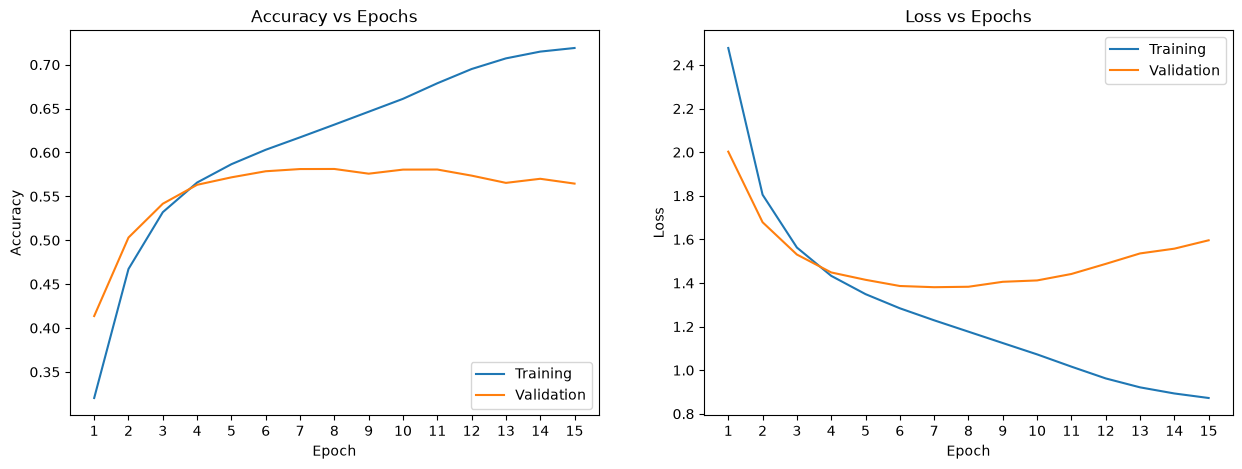

In [47]:
# Accuracy and loss curves, training vs validation
plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(history_dict['sparse_categorical_accuracy'])
plt.plot(history_dict['val_sparse_categorical_accuracy'])
plt.title('Accuracy vs Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.xticks(np.arange(len(history_dict['sparse_categorical_accuracy'])))
ax = plt.gca()
ax.set_xticklabels(1 + np.arange(len(history_dict['sparse_categorical_accuracy'])))
plt.legend(['Training', 'Validation'], loc='lower right')
plt.subplot(122)
plt.plot(history_dict['loss'])
plt.plot(history_dict['val_loss'])
plt.title('Loss vs Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.xticks(np.arange(len(history_dict['sparse_categorical_accuracy'])))
ax = plt.gca()
ax.set_xticklabels(1 + np.arange(len(history_dict['sparse_categorical_accuracy'])))
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

**Reading the curves** (15 epochs):

* The training loss falls from 2.48 to 0.87 and the training accuracy climbs from 32.0% to 71.9%, so the model keeps learning the training data the whole time.
* The validation loss reaches its minimum at **epoch 7 (1.381)** and then goes up to 1.596 by epoch 15. The validation accuracy peaks at about **58.1%** (epochs 7 and 8) and then slowly drops to 56.5%.
* From epoch 7 on, the gap between training and validation keeps growing, which is overfitting: the GRU, with 4M parameters, starts memorizing the training text instead of generalizing.

Because `save_best_only=True` was used, the checkpoint that gets loaded for generation comes from epoch 7, before the overfitting. A loss of 1.38 corresponds to a perplexity of about 4: on average, the model is as uncertain as if it had to choose between 4 equally likely characters.

## 9. Text generation algorithm

For generation, the model is rebuilt with `batch_size=1` and the best weights from training are loaded into it. Three helper functions are then written:

* `get_logits`: runs a token sequence through the embedding, GRU and dense layers (keeping the GRU state between calls) and returns the logits for the next character.
* `sample_token`: picks the next character at random, with the probabilities given by those logits.
* a loop that feeds each sampled character back into the model to build the text step by step.

In [29]:
# Same model with batch_size=1 for generation, then load the trained weights
model = get_model(len(tokenizer.word_index) + 1, batch_size=1)
model.load_weights('./models/ckpt.weights.h5')

In [30]:
# Hidden state of the GRU (all zeros right after loading)
model.layers[1].states

ListWrapper([<Variable path=sequential_1/gru_1/rnn_state, shape=(1, 1024), dtype=float32, value=[[0. 0. 0. ... 0. 0. 0.]]>])

In [34]:
# Run the layers by hand and return the logits of the last time step
def get_logits(model, token_sequence, initial_state=None):

    tensor_sequence_input = tf.convert_to_tensor(
        token_sequence, dtype=tf.int32
    )

    embedding_layer = model.layers[0]
    gru_layer = model.layers[1]
    output_layer = model.layers[2]

    x = embedding_layer(tensor_sequence_input)
    gru_output = gru_layer(x, initial_state=initial_state)
    predictions = output_layer(gru_output)

    logits = predictions[:, -1, :]

    return logits.numpy()

In [35]:
# Quick test of get_logits with a random initial state
dummy_initial_state = tf.random.normal(model.layers[1].states[0].shape)
get_logits(model, [[1, 2, 3, 4]], initial_state = dummy_initial_state)

array([[-8.563111  , -7.3825703 ,  1.9350752 ,  5.4710674 ,  6.0525894 ,
         2.206185  ,  5.0189524 ,  5.776643  ,  3.9317036 ,  6.4247065 ,
         1.0133258 ,  4.6501403 ,  3.531117  , -0.43056086, -1.1471436 ,
         3.1716223 ,  0.81393015,  3.101127  ,  1.7113204 ,  3.9596496 ,
         1.6810064 ,  2.8062541 , -1.923907  , -2.608568  , -0.0271121 ,
        -1.845992  ,  3.5821216 , -3.2200077 , -1.3147725 , -4.96807   ,
        -4.528573  , -1.7899    , -4.927011  , -6.210948  , -5.634552  ,
        -2.6475072 , -4.997909  , -5.0422974 , -4.015238  ,  0.73023957,
        -2.079217  , -5.6305857 , -2.6640096 , -6.764606  , -2.5353057 ,
         2.2323577 , -7.592978  ,  1.1217346 , -9.434876  , -3.239972  ,
        -4.3738894 , -4.7284985 , -5.4797606 , -9.099762  , -7.5047507 ,
        -1.1326511 , -0.7744715 , -9.013179  , -6.1694913 , -6.71275   ,
        -6.998783  , -4.128717  , -7.9341426 , -9.89176   , -4.9082155 ,
        -8.8387165 ]], dtype=float32)

In [36]:
# Sample one token id from the logits
def sample_token(logits):

    logits_tensor = tf.convert_to_tensor(logits, dtype=tf.float32)

    prediction = tf.random.categorical(logits_tensor, num_samples= 1)

    return int(prediction[0,0].numpy())


In [37]:
# Quick test of sample_token
dummy_initial_state = tf.random.normal(model.layers[1].states[0].shape)
dummy_logits = get_logits(model, [[1, 2, 3, 4]], initial_state = dummy_initial_state)
sample_token(dummy_logits)


11

In [38]:
# Sanity check: with two equally likely tokens, only those two get sampled
logits_size = dummy_logits.shape[1]
dummy_logits = -np.inf*np.ones((1, logits_size))
dummy_logits[0, 20] = 0
sample_token(dummy_logits)
random_inx = np.random.choice(logits_size, 2, replace=False)
random_inx1, random_inx2 = random_inx[0], random_inx[1]
print(random_inx1, random_inx2)
dummy_logits = -np.inf*np.ones((1, logits_size))
dummy_logits[0, random_inx1] = 0
dummy_logits[0, random_inx2] = 0
sampled_token = []
for _ in range(100):
    sampled_token.append(sample_token(dummy_logits))
    
l_tokens, l_counts = np.unique(np.array(sampled_token), return_counts=True)
len(l_tokens) == 2


19 35


True

The check returns `True`, so `sample_token` samples only from the tokens that have probability above zero.

## 10. Generating text

The seed string is converted to token ids, then the model predicts one character at a time. After the first step, only the last sampled token is fed in, because the GRU state already remembers everything before it. 1000 characters are generated for each seed.

In [39]:

#Creating a seed string and number of generation steps
init_string = 'ROMEO:'
num_generation_steps = 1000


In [40]:
# Generate token by token, feeding back the sampled token and the GRU state
# Using the model to generate a token sequence

token_sequence = tokenizer.texts_to_sequences([init_string])
initial_state = None
input_sequence = token_sequence

for _ in range(num_generation_steps):
    logits = get_logits(model, input_sequence, initial_state=initial_state)
    sampled_token = sample_token(logits)
    token_sequence[0].append(sampled_token)
    input_sequence = [[sampled_token]]
    initial_state = model.layers[1].states[0].numpy()


# [::2] removes the spaces the tokenizer puts between characters
print(tokenizer.sequences_to_texts(token_sequence)[0][::2])




ROMEO:
Why, here all my celestare at shaken in heaven
Than
Thither, and your penforce you pardon her, he's it to be
The Marcius, when when my wife and buy for pray
Than this is Morbany' law's a baw come to Parman

CORIOLANUS:
Nay, my Doth french a way to fair daunt,
When he is Liciod, leave mount i' the crawn
A taughter and to make the squellemanage:
Is all the peace would ne'er as I can leat

SIIN ANGELE:
He is can by away: will my bower upon her one:
The geeds is loathman beat Our happy is: of garneal,
Than when you's came to have shunders the grave where
If your worshime were into heary begon There?
And, kin, they must enter that the vial and men's
Ampetian that I shall do lember mercy
And perrarly much: for I should be found your face;
But for the vipity, who, 'I'll tell you, go with the infurrent in again,
Had that full of good titings from the enemy
Is builded daughter,; she's a word and hands; after he
will, confixed, I pay me?

PRINCE:
If that my Edward lide, I do a ralfor'd no

**Seed `ROMEO:`**. Even though the model only predicts one character at a time, the text it writes looks like a play:

* It reproduces the script format: speaker names in capitals followed by a colon (`CORIOLANUS:`, `PRINCE:`), a new line for each verse and blank lines between speakers.
* Most words are real English words (*heaven*, *mercy*, *daughter*, *peace*), and there are names taken from the training text (*Marcius*, *Edward*).
* There are also made-up words (*celestare*, *penforce*, *Morbany*) and invented speakers (`SIIN ANGELE`). The sentences follow the rhythm of Shakespeare but they do not really mean anything.

The generation is random: running the cell again gives a different text each time.

In [41]:
#Initializing with other seed:
init_string = 'DIEGO'
num_generation_steps = 1000


In [42]:
# Same generation loop, with the new seed
token_sequence = tokenizer.texts_to_sequences([init_string])
initial_state = None
input_sequence = token_sequence

for _ in range(num_generation_steps):
    logits = get_logits(model, input_sequence, initial_state=initial_state)
    sampled_token = sample_token(logits)
    token_sequence[0].append(sampled_token)
    input_sequence = [[sampled_token]]
    initial_state = model.layers[1].states[0].numpy()


# [::2] removes the spaces the tokenizer puts between characters
print(tokenizer.sequences_to_texts(token_sequence)[0][::2])


DIEGO My husband,
Where it be about, my Lord Lord camulem,
It seems their looks and say what a trade'
And now it not? O my hand nobly she As no harb,
Or whose hand-banith, a quick-kind, E'll play for her!
Plantain'd the queen, fair man that thousand loves me lead;
Of whatficine her man's place and recortable,
And beauty, I, now and moved, my liege, I am sorry,
There is no man bear in gracious most stay of nor;
This case amacuetifuler; here is anvoice
Ill do unless a light's life and death to trick
Than pagan and more feigned oney buzity
Tyat would heeded and all to my wife and
The prince det thee in my brovieding: who hair
Apposing Montague, and in the procestalions;
If you should not lie, ne'er say unto a comm?

HONTENSIO:
Stay you, Tybalt;
And there is a forward wife with you,
With stanks as the news, that drinks of green ofe of anised
Ay, but the pearce at the grief what the petterlay
Of no man is dead, an hois Buposed,
But the necessity Marcius to our king!
By arry eye to himself R

**Seed `DIEGO`**. This word never appears in the training text, but the model still continues from it without problems, and writes a new scene with the same format. Names from the plays show up again (*Tybalt*, *Montague*, *Romeo*) and the model even produces a variant of an existing speaker, `HONTENSIO:`, which looks like a blend of *Hortensio*.

The quality is similar to the first seed: correct structure and plausible words, but with misspellings and no real meaning. That is what is expected from a model that has 58% accuracy predicting the next character.

## 11. Summary and results

### What was done

A character-level language model for Shakespeare's text, built with TensorFlow 2 / Keras:

1. **Data loading**: a text file of about 1.1 million characters, split at full stops into 7,886 chunks.
2. **Tokenization**: a character-level `Tokenizer` (64 different characters, 66 tokens counting `<UNK>` and the padding id), and the chunks converted to integer sequences.
3. **Padding**: every sequence padded or truncated to 500 tokens, giving an array of shape `(7886, 500)`.
4. **Inputs and targets**: the target is the input shifted one character, so the model predicts the next character at every position.
5. **Stateful batching**: examples trimmed to a multiple of the batch size (7,872) and reordered so every batch continues the previous one; 6,272 sequences for training (196 batches) and 1,600 for validation (50 batches).
6. **Model**: `Embedding` (256) -> stateful `GRU` (1024 units) -> `Dense` (66 logits), with 4,022,850 trainable parameters.
7. **Training**: Adam optimizer, `SparseCategoricalCrossentropy(from_logits=True)`, batch size 32, 15 epochs and a `ModelCheckpoint` that keeps the weights with the lowest validation loss.
8. **Generation**: the model rebuilt with `batch_size=1`, the best weights loaded and a sampling loop that writes 1000 characters from a seed string, feeding back each sampled character and the GRU state.

### Results

| Metric | Training (epoch 15) | Validation (best epoch, 7) | Validation (epoch 15) |
|--------|--------------------:|---------------------------:|----------------------:|
| Loss | 0.8725 | 1.3807 | 1.5958 |
| Accuracy | 71.90% | 58.11% | 56.45% |

The weights used to generate the text are those of epoch 7 (validation loss 1.381, perplexity about 4).

### Conclusions

* **The model learns the structure of a play.** Without any rules, it writes speaker names in capitals followed by a colon, short verses and blank lines between speakers.
* **It learns words, but not meaning.** Most of the generated words are real English words, and some are made up. Sentences have a Shakespearean rhythm, but they do not follow a coherent idea.
* **The GRU overfits after epoch 7.** Training loss keeps going down while validation loss goes up, so more epochs would not help. Saving only the best checkpoint avoided using the overfitted weights.
* **Next-character accuracy of 58% is a reasonable result.** Predicting the exact next character in free text is hard, since many characters are valid in the same place.

### Possible improvements

* Add dropout (or recurrent dropout) and use `EarlyStopping` to reduce the overfitting.
* Use a temperature in the sampling to control how risky the generated text is.
* Train on more text, or try a bigger or stacked recurrent model (several GRU or LSTM layers).
* Compare the GRU with an LSTM or a Transformer under the same conditions.